Загрузка данных из бд

In [30]:
import sys
sys.path.append('..')
from data import db
import pandas as pd 
conn = db.get_connection()

df = pd.read_sql("""
    SELECT id,title, tags,description,genre
    FROM books
    WHERE tags IS NOT NULL
    AND description IS NOT NULL
""", conn)
df.head()

/var/folders/kl/zp9l_8715tz323g6x87w7pvh0000gn/T/ipykernel_14094/1098795928.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""


,id,title,tags,description,genre
0,1568,Надежда Тэффи «СВОИ и ЧУЖИЕ»,"{'topics': [], 'topic_label': 'Пьесы и истории...",Юмористический рассказ об особенностях общения...,Классическая литература
1,445,Сонеты,"{'topics': [], 'topic_label': 'Русская классич...",Сонеты Уильяма Шекспира — одна из самых извест...,Поэзия и драматургия
2,2354,Зеркало старой ведьмы,"{'topics': [], 'topic_label': 'Женские судьбы:...",Кто поможет Тимке вернуться домой из Закрытого...,Повести
3,441,Мцыри,"{'topics': [], 'topic_label': 'Русская классич...",Один из последних образцов русской романтическ...,Поэзия и драматургия
4,1111,Выбор Софи,{'topics': [{'label': 'книга о войне и военном...,"""Выбор Софи"" (1979) — один из самых лучших ром...",Зарубежная литература


In [31]:
def get_themes(tags):
    if tags.get('topic_label'):
        return tags['topic_label']
    return [t['label'] for t in sorted(tags['topics'], key=lambda t: t['score'], reverse=True)[:3]]

df['themes'] = df['tags'].apply(get_themes)
df['themes'].head()

0                              Пьесы и истории о людях
1                  Русская классическая поэзия и поэмы
2                  Женские судьбы: матери, дочери, мир
3                  Русская классическая поэзия и поэмы
4    [книга о войне и военном конфликте, книга о вы...
Name: themes, dtype: object

Создать столбец с главными темами (топ 3 тем, классифицированнных с помощью зиро-шот)

In [32]:
df['themes'].head(20)

0                               Пьесы и истории о людях
1                   Русская классическая поэзия и поэмы
2                   Женские судьбы: матери, дочери, мир
3                   Русская классическая поэзия и поэмы
4     [книга о войне и военном конфликте, книга о вы...
5                   Русская классическая поэзия и поэмы
6                   Русская классическая поэзия и поэмы
7                               Пьесы и истории о людях
8                   Женские судьбы: матери, дочери, мир
9                               Пьесы и истории о людях
10                              Пьесы и истории о людях
11                  Женские судьбы: матери, дочери, мир
12                  Женские судьбы: матери, дочери, мир
13           Классическая философия: история и переводы
14                  Русская классическая поэзия и поэмы
15                   [книга о взрослении и поиске себя]
16                  Женские судьбы: матери, дочери, мир
17                  Женские судьбы: матери, доче

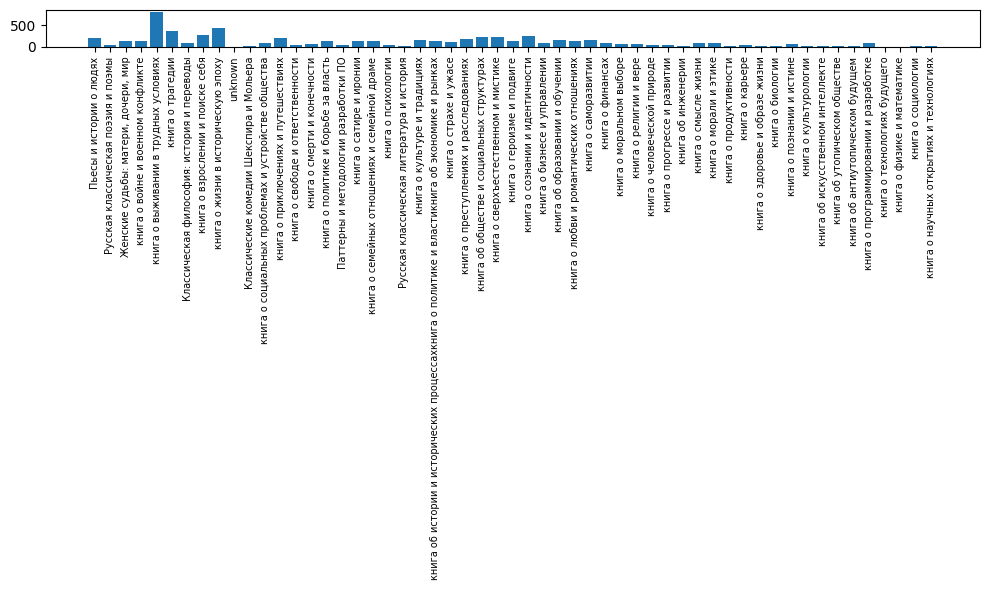

In [33]:
from collections import Counter
import matplotlib.pyplot as plt
all_themes = []
for t in df['themes']:
    if isinstance(t, list):
        all_themes.extend(t)
    else:
        all_themes.append(t)

counts = Counter(all_themes)
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x=range(len(counts)), height=counts.values())
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(counts.keys(), rotation=90, fontsize=7)
plt.tight_layout()



Итого 55 кластеров 
"Истории о выживании в трудных условиях появляется в большинстве книг, возможно, стоит исключить эту категорию, так как она слишком абстрактна 

In [34]:
avg = df['tags'].apply(lambda x: next((t['score'] for t in x.get('topics', []) if t['label'] == 'книга о выживании в трудных условиях'), None)).dropna().mean()
print(avg)

0.7517998517470987


Оставим эту категорию.

<h1> Оценка Метрик</h1>

Оценим кластеризацию с помощью берт-топик

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics import silhouette_score

# 1. Embed
df = df.reset_index(drop=True)
df_topic_label = df[df['tags'].apply(lambda x: bool(x.get('topic_label')))]
df_zeroshot = df[df['tags'].apply(lambda x: bool(x.get('topics')))]
model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
embeddings_tl = model.encode(df_topic_label['description'].tolist(), show_progress_bar=True)

# 2. Labels
labels = df_topic_label['themes']

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/17 [00:00<?, ?it/s]

Silhouette Score: 0.006


Рассмотрим кластеры в более низкой размерности 

In [ ]:
import umap
import seaborn as sns
import matplotlib.pyplot as plt

# Reduce to 2D
reducer = umap.UMAP(n_components=2, random_state=42)
embedding_2d = reducer.fit_transform(embeddings_tl)

# Plot
sns.scatterplot(
    x=embedding_2d[:, 0],
    y=embedding_2d[:, 1],
    hue=labels,
    s=20
)

plt.show()